In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import huracanpy
from cartopy.crs import EqualEarth
from huracanpy.plot import fancyline
import seaborn as sns
from tc_helpers import *

In [2]:
tracks = load_syclops()

10kmCoMorph TC tracks loaded successfully
10kmGAL TC tracks loaded successfully
5kmCoMorph TC tracks loaded successfully
5kmRAL TC tracks loaded successfully


/home/users/l_grant/.conda/envs/hk26_env/lib/python3.14/site-packages/huracanpy/_data/ibtracs.py:119: UserWarning: This offline function loads a light version of IBTrACS which is embedded within the package, based on a file produced manually by the developers.
 It was last updated on the 15th Nov 2024, based on the IBTrACS file at that date.
 It contains only data from 1980 up to the last year with no provisional tracks. All spur tracks were removed. Only 6-hourly time steps were kept.
  warnings.warn(


JTWC tracks loaded successfully


In [3]:
for name,ds in tracks.items():
    ds_tmp = compute_intensification_rate(ds, var='sfcwind_max', timedelta=6)
    tracks[name] = compute_intensification_rate(ds_tmp, var='psl_min', timedelta=6)

24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr
24hr intensification rate calculated, units are knots/24hr
24hr intensification rate calculated, units are hPa/24hr


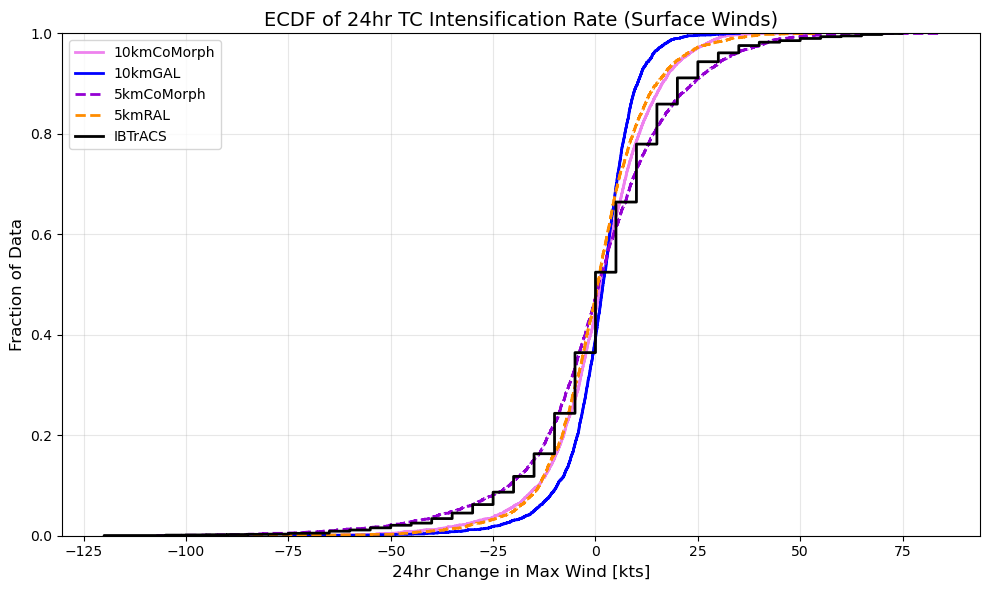

In [12]:
# Single ECDF plot with all model configs and basic axes for ease
fig, ax = plt.subplots(figsize=(10, 6))

for name, ds in tracks.items():
    # Strip nans from rates 
    rates = ds.wind_ir_24hr.dropna(dim='record')
    # 
    # Plot ECDF
    ax.ecdf(rates, label=name, linewidth=2, color= hk26_colours.get(name, None), 
            linestyle=hk26_linestyles.get(name, '-'))

ax.set_xlabel('24hr Change in Max Wind [kts]', fontsize=12)
ax.set_ylabel('Fraction of Data', fontsize=12)
ax.set_title('ECDF of 24hr TC Intensification Rate (Surface Winds)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim()
plt.tight_layout()
plt.show()

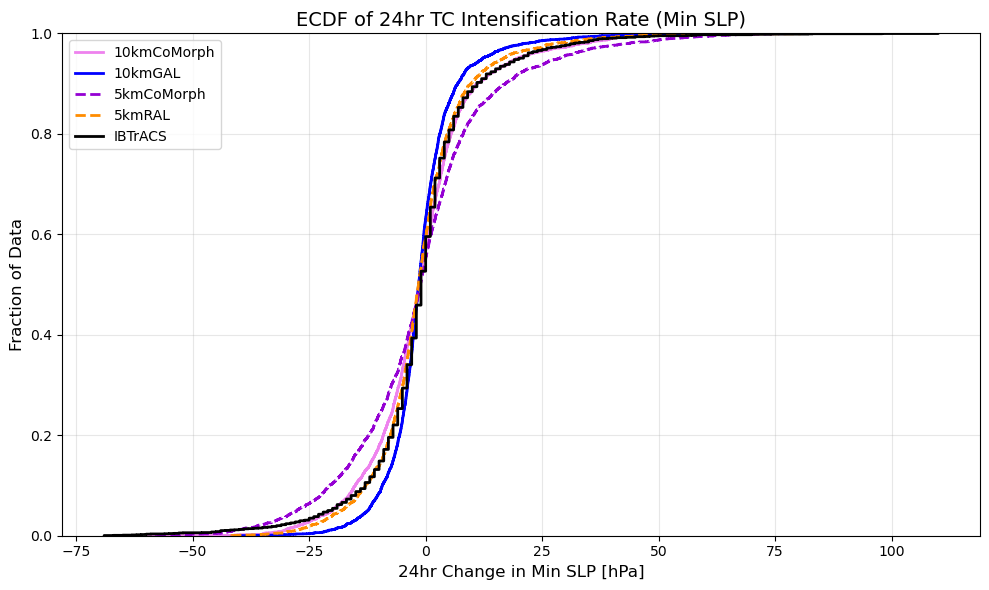

In [14]:
# Repeat for pressure
fig, ax = plt.subplots(figsize=(10, 6))

for name, ds in tracks.items():
    # Strip nans from rates 
    rates = ds.pres_ir_24hr.dropna(dim='record')
    # 
    # Plot ECDF
    ax.ecdf(rates, label=name, linewidth=2, color=hk26_colours.get(name, None),
            linestyle=hk26_linestyles.get(name, '-'))

ax.set_xlabel('24hr Change in Min SLP [hPa]', fontsize=12)
ax.set_ylabel('Fraction of Data', fontsize=12)
ax.set_title('ECDF of 24hr TC Intensification Rate (Min SLP)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

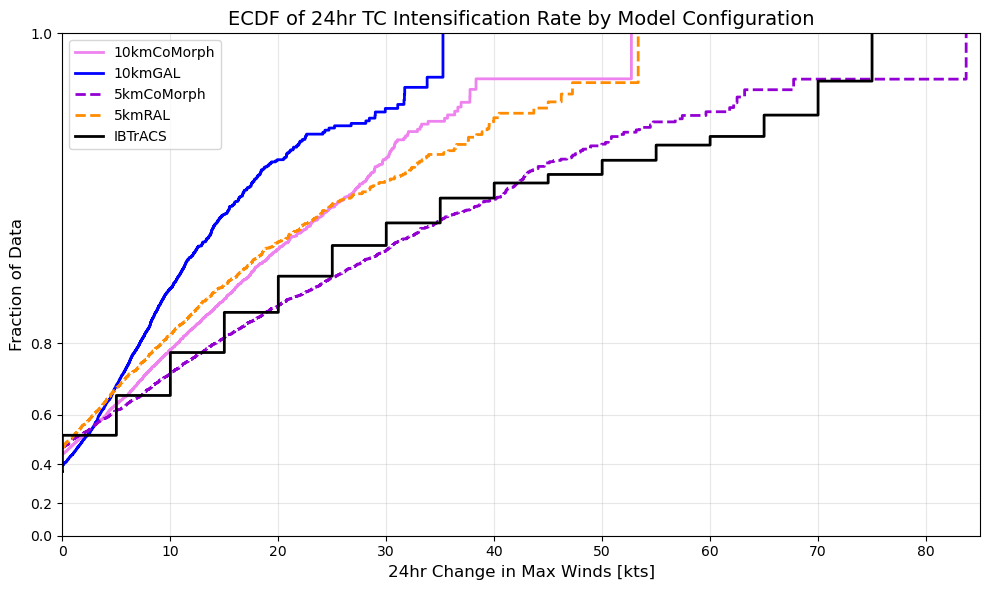

In [8]:
# Single ECDF plot with all model configs
fig, ax = plt.subplots(figsize=(10, 6))

for name, ds in tracks.items():
    # Strip nans from rates 
    rates = ds.wind_ir_24hr.dropna(dim='record')
    # 
    # Plot ECDF
    ax.ecdf(rates, label=name, linewidth=2, color= hk26_colours.get(name, None), 
            linestyle=hk26_linestyles.get(name, '-'))

ax.set_xlabel('24hr Change in Max Winds [kts]', fontsize=12)
ax.set_ylabel('Fraction of Data', fontsize=12)
ax.set_title('ECDF of 24hr TC Intensification Rate by Model Configuration', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0,85])
ax.set_yscale('function', functions=(lambda x: 1- (1-x)**0.3, lambda x: 1 - (1- x)**(1/0.3)))
ax.set_ylim([0,1])
plt.tight_layout()
plt.show()

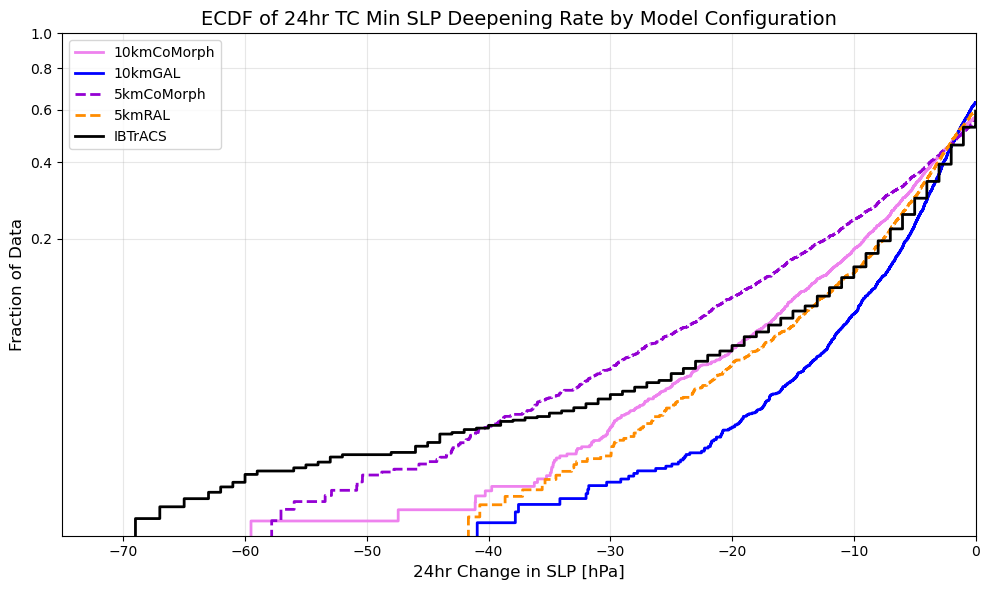

In [9]:
# Single ECDF plot with all model configs
fig, ax = plt.subplots(figsize=(10, 6))

for name, ds in tracks.items():
    # Strip nans from rates 
    rates = ds.pres_ir_24hr.dropna(dim='record')
    # 
    # Plot ECDF
    ax.ecdf(rates, label=name, linewidth=2, color=hk26_colours.get(name, None),
            linestyle=hk26_linestyles.get(name, '-'))

ax.set_xlabel('24hr Change in SLP [hPa]', fontsize=12)
ax.set_ylabel('Fraction of Data', fontsize=12)
ax.set_title('ECDF of 24hr TC Min SLP Deepening Rate by Model Configuration', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([-75,0])
ax.set_yscale('function', functions=(lambda x: x**0.3, lambda x: x**(1/0.3)))
ax.set_ylim([0.0001,1])
plt.tight_layout()
plt.show()